# Question A：分类问题中的熵

本题讨论决策树或其他分类算法中，熵如何衡量一个划分后的节点是否“纯”。

## 答案概览

| 判断 | 结论 | 理由 |
|---|---|---|
| (a) High entropy means the partitions are pure. | **False** | 高熵表示类别混杂，节点不纯。 |
| (b) High entropy means the partitions are impure. | **True** | 在二分类中，正负样本越接近 50%/50%，熵越高，不确定性越大。 |

## 理论解释

对分类问题中的一个节点或分区，熵定义为：

$$H(S)=-\sum_{k=1}^{K}p_k\log_2(p_k)$$

其中 $p_k$ 是该节点中第 $k$ 类样本所占比例。熵衡量的是类别标签的不确定性，而不是模型误差本身。

对于二分类问题，若正类比例为 $p$，负类比例为 $1-p$，则：

$$H(p)=-p\log_2(p)-(1-p)\log_2(1-p)$$

当一个节点中几乎全是同一类样本时，类别非常确定，熵接近 0，节点较纯。当两类样本比例接近 50% 和 50% 时，类别最难判断，熵达到最大值 1，节点最不纯。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


def binary_entropy(p):
    p = np.asarray(p, dtype=float)
    q = 1 - p
    out = np.zeros_like(p, dtype=float)
    mask = (p > 0) & (p < 1)
    out[mask] = -p[mask] * np.log2(p[mask]) - q[mask] * np.log2(q[mask])
    return out


examples = pd.DataFrame({"正类比例": [0.00, 0.10, 0.25, 0.50, 0.75, 0.90, 1.00]})
examples["负类比例"] = 1 - examples["正类比例"]
examples["熵"] = binary_entropy(examples["正类比例"]).round(4)
examples

,正类比例,负类比例,熵
0,0.00,1.00,0.0000
1,0.10,0.90,0.4690
2,0.25,0.75,0.8113
3,0.50,0.50,1.0000
4,0.75,0.25,0.8113
5,0.90,0.10,0.4690
6,1.00,0.00,0.0000


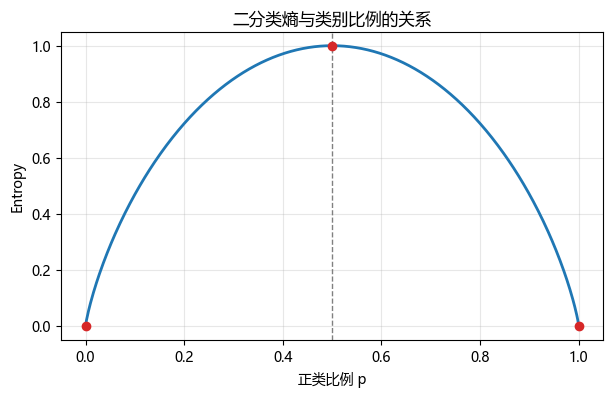

In [2]:
p = np.linspace(0, 1, 501)
h = binary_entropy(p)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p, h, color="#1f77b4", linewidth=2)
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)
ax.scatter([0, 0.5, 1], [0, 1, 0], color="#d62728", zorder=3)
ax.set_title("二分类熵与类别比例的关系")
ax.set_xlabel("正类比例 p")
ax.set_ylabel("Entropy")
ax.grid(True, alpha=0.3)
plt.show()

## 结论

因此，(a) 是 **False**，(b) 是 **True**。熵越低，说明划分后的节点中某一类别越占主导，节点越纯；熵越高，说明不同类别混在一起的程度越高，节点越不纯。决策树在选择分裂变量时，通常会寻找能够最大幅度降低熵的划分，也就是最大化信息增益。